# Imagenette Repeated Optical Network

This notebook explains the Imagenette pipeline separately from the MNIST experiments.

Learning goals:

1. Understand the image-to-token pipeline for Imagenette.
2. See how time multiplexing feeds many patch vectors through a width-16 optical core.
3. Read the Flax module structure for the repeated optical core.
4. Visualize patches, tokens, and pooled output features.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"Project root: {ROOT}")

RNG_SEED = 7

try:
    import numpy as np
    np.random.seed(RNG_SEED)
except ImportError:
    pass

print(f"Deterministic seed: {RNG_SEED}")


Project root: /Volumes/Storage/Github/Lumix
Deterministic seed: 7


## Imagenette Data Path

The intended pipeline is:

1. Load Imagenette images.
2. Resize/downsample.
3. Split into non-overlapping patches.
4. Flatten each patch to a width-16 token when using 4x4 patches, or reduce larger patches to width 16 before the optical core.
5. Time-multiplex the tokens through the same optical core.
6. Pool token outputs.
7. Train a digital readout.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

imagenette_root = ROOT / "data" / "imagenette2-160"
image_paths = sorted(imagenette_root.glob("train/*/*.JPEG")) if imagenette_root.exists() else []
print("Imagenette root exists:", imagenette_root.exists())
print("example image count found:", len(image_paths))


Imagenette root exists: True
example image count found: 9469


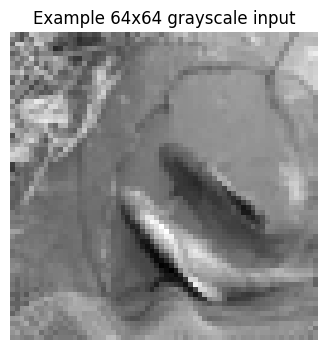

In [3]:
try:
    from PIL import Image
except ImportError:
    Image = None

if image_paths and Image is not None:
    image = Image.open(image_paths[0]).convert("L").resize((64, 64))
    image_array = np.asarray(image, dtype=np.float32) / 255.0
else:
    yy, xx = np.mgrid[:64, :64]
    image_array = ((np.sin(xx / 5) + np.cos(yy / 7)) > 0).astype(np.float32)

plt.figure(figsize=(4, 4))
plt.imshow(image_array, cmap="gray")
plt.title("Example 64x64 grayscale input")
plt.axis("off")
plt.show()


4x4 patches: (256, 4, 4)
all flattened row tokens: (256, 16)
selected 4x4 patch: (4, 4)
selected patch row token: (1, 16)


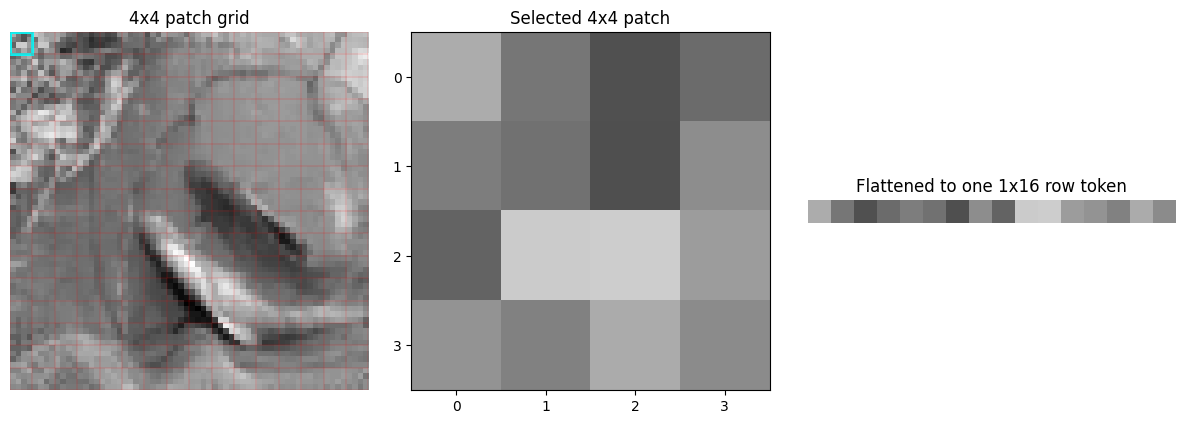

In [4]:
def extract_nonoverlapping_patches(image, patch_size=4):
    height, width = image.shape
    assert height % patch_size == 0 and width % patch_size == 0
    patches = image.reshape(height // patch_size, patch_size, width // patch_size, patch_size)
    patches = patches.transpose(0, 2, 1, 3)
    return patches.reshape(-1, patch_size, patch_size)

patches = extract_nonoverlapping_patches(image_array, patch_size=4)
tokens = patches.reshape(patches.shape[0], -1)

selected_patch_index = 0
selected_patch = patches[selected_patch_index]
selected_patch_row = selected_patch.reshape(1, -1)

print("4x4 patches:", patches.shape)
print("all flattened row tokens:", tokens.shape)
print("selected 4x4 patch:", selected_patch.shape)
print("selected patch row token:", selected_patch_row.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_array, cmap="gray")
for pos in range(0, 65, 4):
    axes[0].axhline(pos - 0.5, color="red", lw=0.3, alpha=0.5)
    axes[0].axvline(pos - 0.5, color="red", lw=0.3, alpha=0.5)
axes[0].add_patch(plt.Rectangle((-0.5, -0.5), 4, 4, fill=False, edgecolor="cyan", linewidth=2.0))
axes[0].set_title("4x4 patch grid")
axes[0].axis("off")

axes[1].imshow(selected_patch, cmap="gray", vmin=image_array.min(), vmax=image_array.max())
axes[1].set_title("Selected 4x4 patch")
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))

axes[2].imshow(selected_patch_row, cmap="gray", aspect="equal", vmin=image_array.min(), vmax=image_array.max())
axes[2].set_title("Flattened to one 1x16 row token")
axes[2].set_box_aspect(1 / 16)
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Flax Optical Core

The optical core processes all time-multiplexed tokens with shared module code. The leading token dimension is just a batch-like dimension for the optical layer.


In [5]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from lumix.linen import InformationEncoder, IntensityReadout, UnitaryLinear

class ImagenetteRepeatedOpticalCore(nn.Module):
    width: int = 16
    depth: int = 4
    alpha: float = float(jnp.pi)

    @nn.compact
    def __call__(self, patch_vectors, return_fields=False):
        encoder = InformationEncoder(mode="phase", normalize=False)
        phase_mask = encoder(self.alpha * patch_vectors)
        amplitude = jnp.sqrt(jnp.asarray(1.0 / self.width, dtype=jnp.float32))
        fields = jnp.full((*patch_vectors.shape[:-1], self.width), amplitude, dtype=jnp.complex64)

        for layer_index in range(self.depth):
            fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields * phase_mask)

        intensities = IntensityReadout()(fields)
        return (intensities, fields) if return_fields else intensities

class ImagenetteDigitalReadout(nn.Module):
    classes: int = 10

    @nn.compact
    def __call__(self, pooled_features):
        return nn.Dense(self.classes)(pooled_features)

batch_tokens = jnp.asarray(tokens[:8], dtype=jnp.float32)
core = ImagenetteRepeatedOpticalCore(depth=2)
variables = core.init(jax.random.key(RNG_SEED), batch_tokens)
intensities, fields = core.apply(variables, batch_tokens, return_fields=True)
print("token intensities:", intensities.shape)
print("fields:", fields.shape)


token intensities: (8, 16)
fields: (8, 16)


all token features: (256, 16)
pooled features: (16, 16)


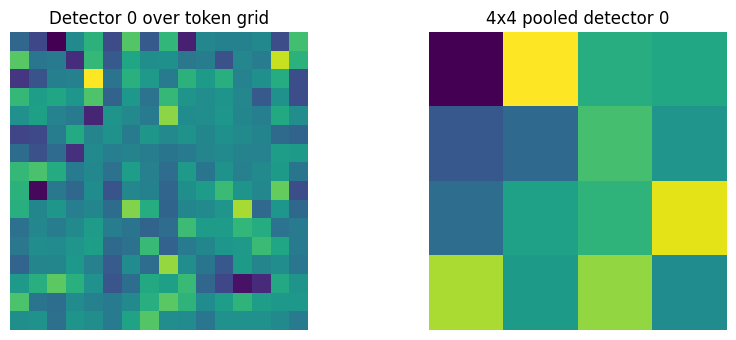

In [6]:
def average_pool_tokens(token_features, grid_size=16, pool_size=4):
    # token_features shape: [grid_size * grid_size, channels]
    channels = token_features.shape[-1]
    grid = token_features.reshape(grid_size, grid_size, channels)
    pooled = grid.reshape(grid_size // pool_size, pool_size, grid_size // pool_size, pool_size, channels)
    pooled = pooled.mean(axis=(1, 3))
    return pooled.reshape(-1, channels)

all_intensities = core.apply(variables, jnp.asarray(tokens, dtype=jnp.float32))
pooled = average_pool_tokens(np.asarray(all_intensities), grid_size=16, pool_size=4)
print("all token features:", all_intensities.shape)
print("pooled features:", pooled.shape)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(np.asarray(all_intensities)[:, 0].reshape(16, 16), cmap="viridis")
axes[0].set_title("Detector 0 over token grid")
axes[0].axis("off")
axes[1].imshow(pooled[:, 0].reshape(4, 4), cmap="viridis")
axes[1].set_title("4x4 pooled detector 0")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Training Pattern

A full training notebook should use the same Flax/Optax structure as the MNIST notebooks: initialize `params`, create `opt_state`, define `loss_fn`, JIT `train_step` and `eval_step`, then plot train/validation curves.

The full Imagenette parameter-sharing training loop is implemented explicitly in notebook 06. This notebook focuses on the data path and Flax architecture shape.


## Exercise

Change the patch size from `4` to `16`. What additional compression step is needed before the width-16 optical core can process each patch?
